# Crypto RSI ETL Pipeline
### A data engineering project that extracts live cryptocurrency trading indicators 
from a financial API, transforms the raw JSON data, and loads it into a MySQL database.

**Tools used:** Python, Pandas, MySQL, Jupyter Notebook, RapidAPI  
**Data:** RSI (Relative Strength Index) for BTC, ETH, and SOL — 1,461 rows  
**Author:** Lans Odidi

In [5]:
# Cell 1 — Install & import libraries
import requests
import pandas as pd
import mysql.connector
from datetime import datetime

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
import subprocess
subprocess.run(["pip", "install", "mysql-connector-python"])

CompletedProcess(args=['pip', 'install', 'mysql-connector-python'], returncode=0)

## Cell 2 — Extract
This cell is created to call the latest data of BTC, ETH, and SOL by looping 
through three symbols because the API only allows one coin per request.

- **API:** Crypto Trading Indicators via RapidAPI
- **Endpoint:** RSI (Relative Strength Index)
- **Parameters:** 14-day period, daily timeframe

In [29]:
# Cell 2 — Extract (multiple coins)
import time

url = "https://crypto-technical-analysis-indicator-apis-for-trading.p.rapidapi.com/rsi"

headers = {
    "x-rapidapi-key": "35fc30eb66msh899b2c2d7f10174p136c04jsn67811c9826fa",
    "x-rapidapi-host": "crypto-technical-analysis-indicator-apis-for-trading.p.rapidapi.com",
    "Content-Type": "application/json"
}

symbols = ["BTCUSDT", "ETHUSDT", "SOLUSDT"]
all_raw_data = {}

for symbol in symbols:
    params = {
        "length": "14",
        "timeframe": "1d",
        "symbol": symbol
    }
    response = requests.get(url, headers=headers, params=params)
    all_raw_data[symbol] = response.json()
    print(f"{symbol}: status {response.status_code}, rows {len(response.json()['rsi'])}")
    time.sleep(1)  # be polite to the API

BTCUSDT: status 200, rows 487
ETHUSDT: status 200, rows 487
SOLUSDT: status 200, rows 487


## Cell 3 — Transform
This cell cleans the data by extracting the time, RSI, and close price from 
the raw JSON response for each coin and organizes it into a neat DataFrame format.

- **Input:** Raw JSON from the API containing nested RSI data
- **Output:** A clean pandas DataFrame with 1,461 rows across BTC, ETH, and SOL

In [35]:
# Cell 3 — Transform (multiple coins)
cleaned_data = []

for symbol, data in all_raw_data.items():
    rsi_list = data["rsi"]
    for entry in rsi_list:
        cleaned_data.append({
            "symbol": symbol,
            "time": datetime.fromtimestamp(entry["time"] / 1000),
            "close_price": float(entry["close"]),
            "rsi": float(entry["rsi"])
        })

df = pd.DataFrame(cleaned_data)
print(f"Total rows: {len(df)}")
print(df.groupby('symbol').size())
print(df.head(10))

Total rows: 1461
symbol
BTCUSDT    487
ETHUSDT    487
SOLUSDT    487
dtype: int64
    symbol                time  close_price        rsi
0  BTCUSDT 2026-03-26 19:00:00      65673.9  39.691284
1  BTCUSDT 2026-03-25 19:00:00      68788.0  46.138871
2  BTCUSDT 2026-03-24 19:00:00      71297.5  52.523332
3  BTCUSDT 2026-03-23 19:00:00      70523.9  50.565234
4  BTCUSDT 2026-03-22 19:00:00      70865.9  51.436091
5  BTCUSDT 2026-03-21 19:00:00      67830.6  43.403075
6  BTCUSDT 2026-03-20 19:00:00      68881.5  45.840845
7  BTCUSDT 2026-03-19 19:00:00      70472.7  49.771173
8  BTCUSDT 2026-03-18 19:00:00      69887.4  48.255845
9  BTCUSDT 2026-03-17 19:00:00      71202.9  51.498301


## Cell 4 — Load
This cell loads the cleaned DataFrame into MySQL by connecting to the server, 
using cursor to select and create a SQL table filled with rows of the cleaned DataFrame.

- **Database:** binance (created automatically if it doesn't exist)
- **Table:** crypto_rsi
- **Rows inserted:** 1,461 (487 per coin)

In [37]:
# Cell 4 — Load

# First connect WITHOUT specifying a database
conn = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="root123"
)

cursor = conn.cursor()

# Create the database if it doesn't exist
cursor.execute("CREATE DATABASE IF NOT EXISTS binance")
cursor.execute("USE binance")

# Create table
cursor.execute("""
    CREATE TABLE IF NOT EXISTS crypto_rsi (
        id INT AUTO_INCREMENT PRIMARY KEY,
        symbol VARCHAR(20),
        time DATETIME,
        close_price FLOAT,
        rsi FLOAT
    )
""")

# Insert rows
for _, row in df.iterrows():
    cursor.execute("""
        INSERT INTO crypto_rsi (symbol, time, close_price, rsi)
        VALUES (%s, %s, %s, %s)
    """, (row["symbol"], row["time"], row["close_price"], row["rsi"]))

conn.commit()
cursor.close()
conn.close()

print(f"Successfully loaded {len(df)} rows into MySQL!")

Successfully loaded 1461 rows into MySQL!


## Cell 5 — Visualization
This cell creates a three panel dashboard visualizing the RSI and price data 
for BTC, ETH, and SOL using matplotlib.

- **Panel 1:** RSI over time with overbought (70) and oversold (30) zones highlighted
- **Panel 2:** Latest RSI comparison across all three coins
- **Panel 3:** Closing price over time in USD

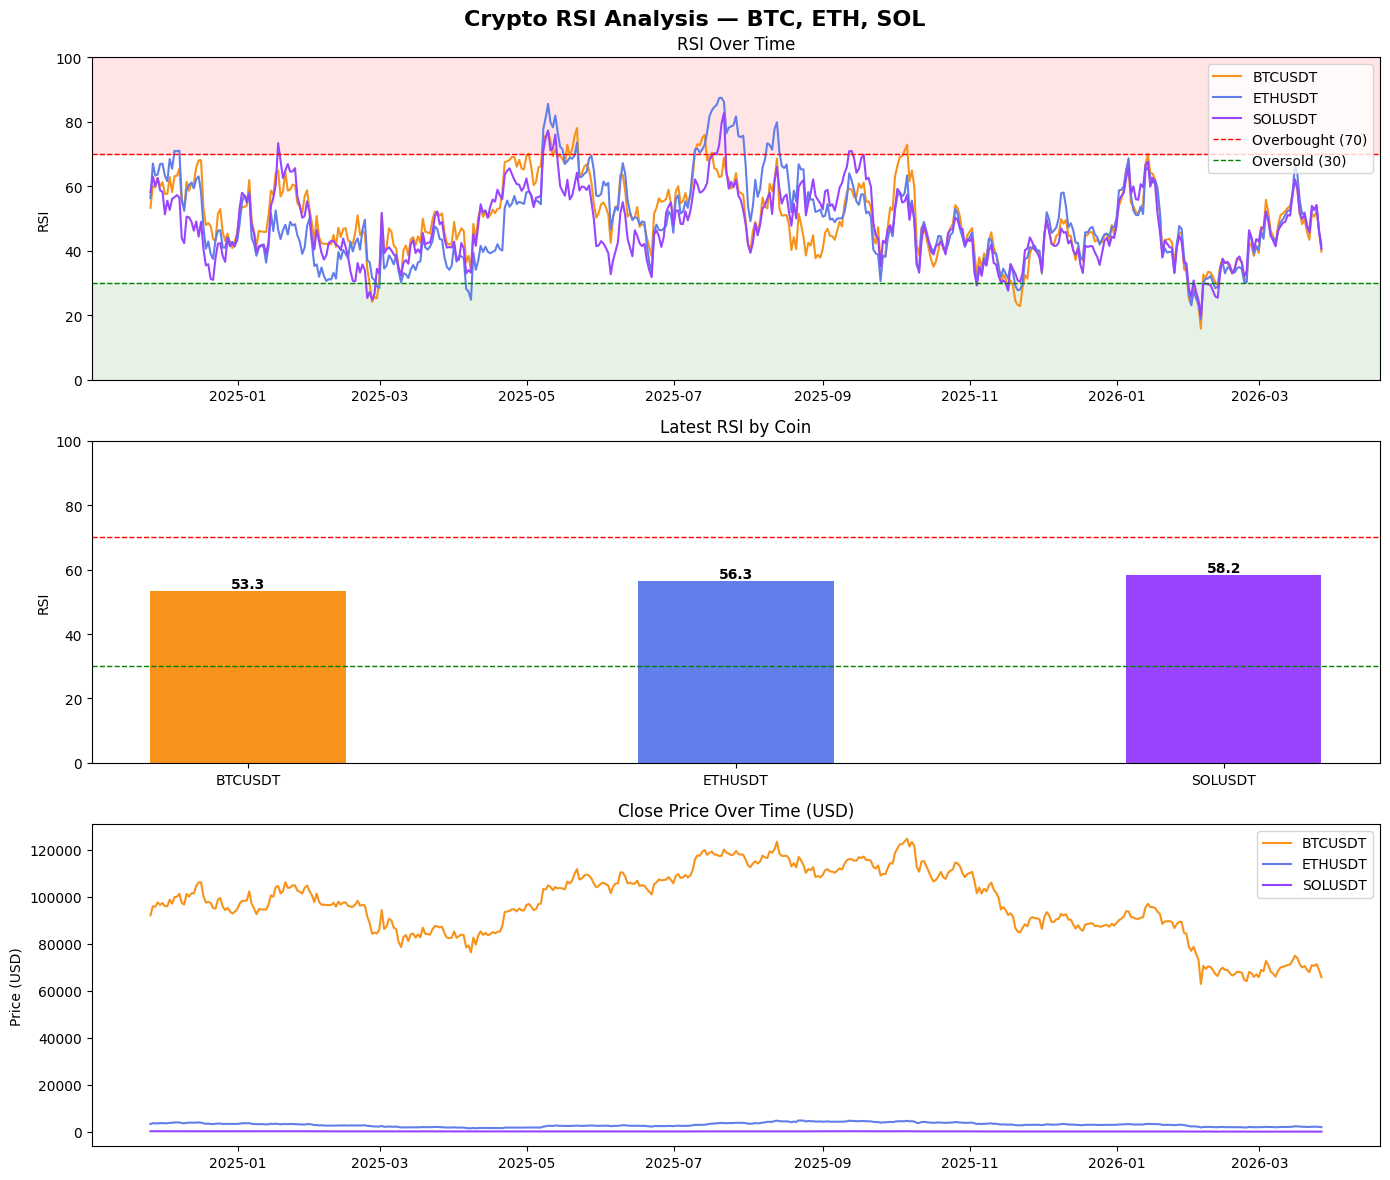

Chart saved as crypto_rsi_analysis.png


In [39]:
# Cell 5 — Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Crypto RSI Analysis — BTC, ETH, SOL', fontsize=16, fontweight='bold')

colors = {"BTCUSDT": "#F7931A", "ETHUSDT": "#627EEA", "SOLUSDT": "#9945FF"}

# Panel 1 — RSI over time
ax1 = axes[0]
for symbol, group in df.groupby("symbol"):
    ax1.plot(group["time"], group["rsi"], label=symbol, color=colors[symbol], linewidth=1.5)
ax1.axhline(y=70, color="red", linestyle="--", linewidth=1, label="Overbought (70)")
ax1.axhline(y=30, color="green", linestyle="--", linewidth=1, label="Oversold (30)")
ax1.axhspan(0, 30, alpha=0.1, color="green")
ax1.axhspan(70, 100, alpha=0.1, color="red")
ax1.set_title("RSI Over Time")
ax1.set_ylabel("RSI")
ax1.legend(loc="upper right")
ax1.set_ylim(0, 100)

# Panel 2 — Latest RSI bar chart
ax2 = axes[1]
latest = df.groupby("symbol").last().reset_index()
bars = ax2.bar(latest["symbol"], latest["rsi"], 
               color=[colors[s] for s in latest["symbol"]], width=0.4)
ax2.axhline(y=70, color="red", linestyle="--", linewidth=1)
ax2.axhline(y=30, color="green", linestyle="--", linewidth=1)
for bar, val in zip(bars, latest["rsi"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.1f}", ha="center", fontweight="bold")
ax2.set_title("Latest RSI by Coin")
ax2.set_ylabel("RSI")
ax2.set_ylim(0, 100)

# Panel 3 — Close price over time
ax3 = axes[2]
for symbol, group in df.groupby("symbol"):
    ax3.plot(group["time"], group["close_price"], 
             label=symbol, color=colors[symbol], linewidth=1.5)
ax3.set_title("Close Price Over Time (USD)")
ax3.set_ylabel("Price (USD)")
ax3.legend(loc="upper right")

plt.tight_layout()
plt.savefig("crypto_rsi_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as crypto_rsi_analysis.png")